In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('../data/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [14]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [15]:
df.isna().sum()


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#Exploratory Data Analysis

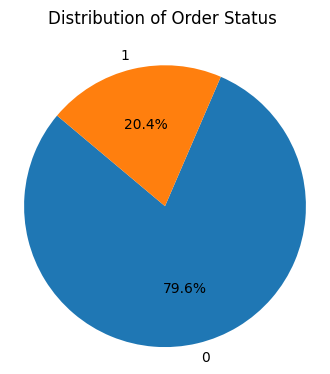

In [16]:
plt.figure(figsize=(4,4))
output_counts = df['Exited'].value_counts()
plt.pie(output_counts, labels=output_counts.index, autopct='%1.1f%%', startangle=140)

plt.axis('equal')
plt.title('Distribution of Order Status \n')
plt.ylabel('')

plt.show()



**Observation:**

The target column looks imbalanced - accuracy would not be a good metric to evaluate the model and we would need to apply balancing techniques like SMOTE while modeling


Box plot for numerical features:


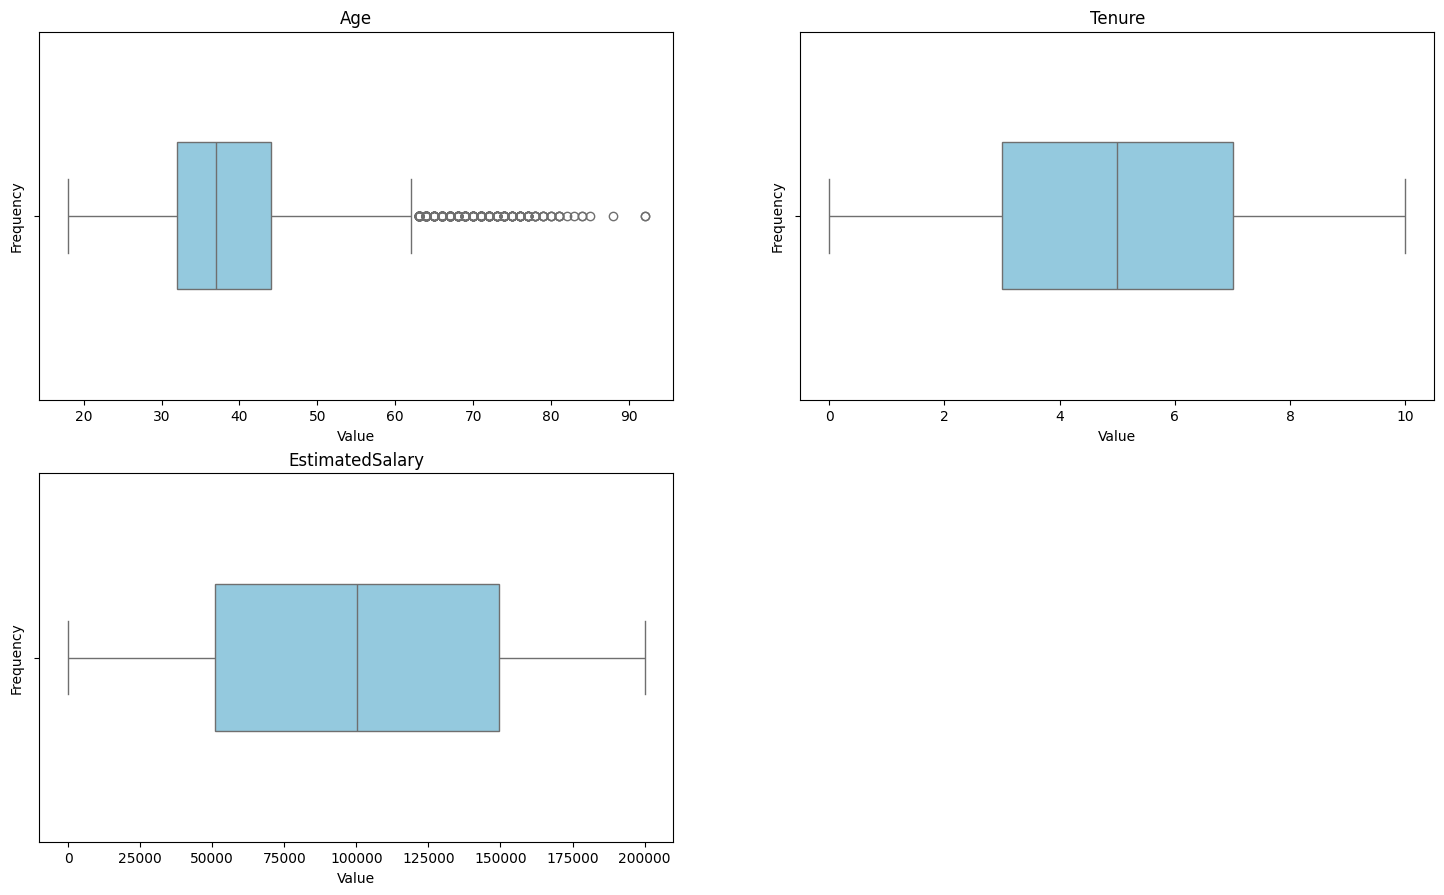

In [17]:
print("Box plot for numerical features:")
plt.figure(figsize=(18,22))
numeric_features = ['Age','Tenure','EstimatedSalary']
for i, column in enumerate(numeric_features):
    plt.subplot(4,2, i + 1)
    sns.boxplot(x=df[column], color='skyblue', width=0.4)
    plt.title(column)
    plt.xlabel('Value')
    plt.ylabel('Frequency')


**Observation:**

It does not look like there are many outliers in the numerical features, except Age - but we can't do much about it


Count plot for categorical features:


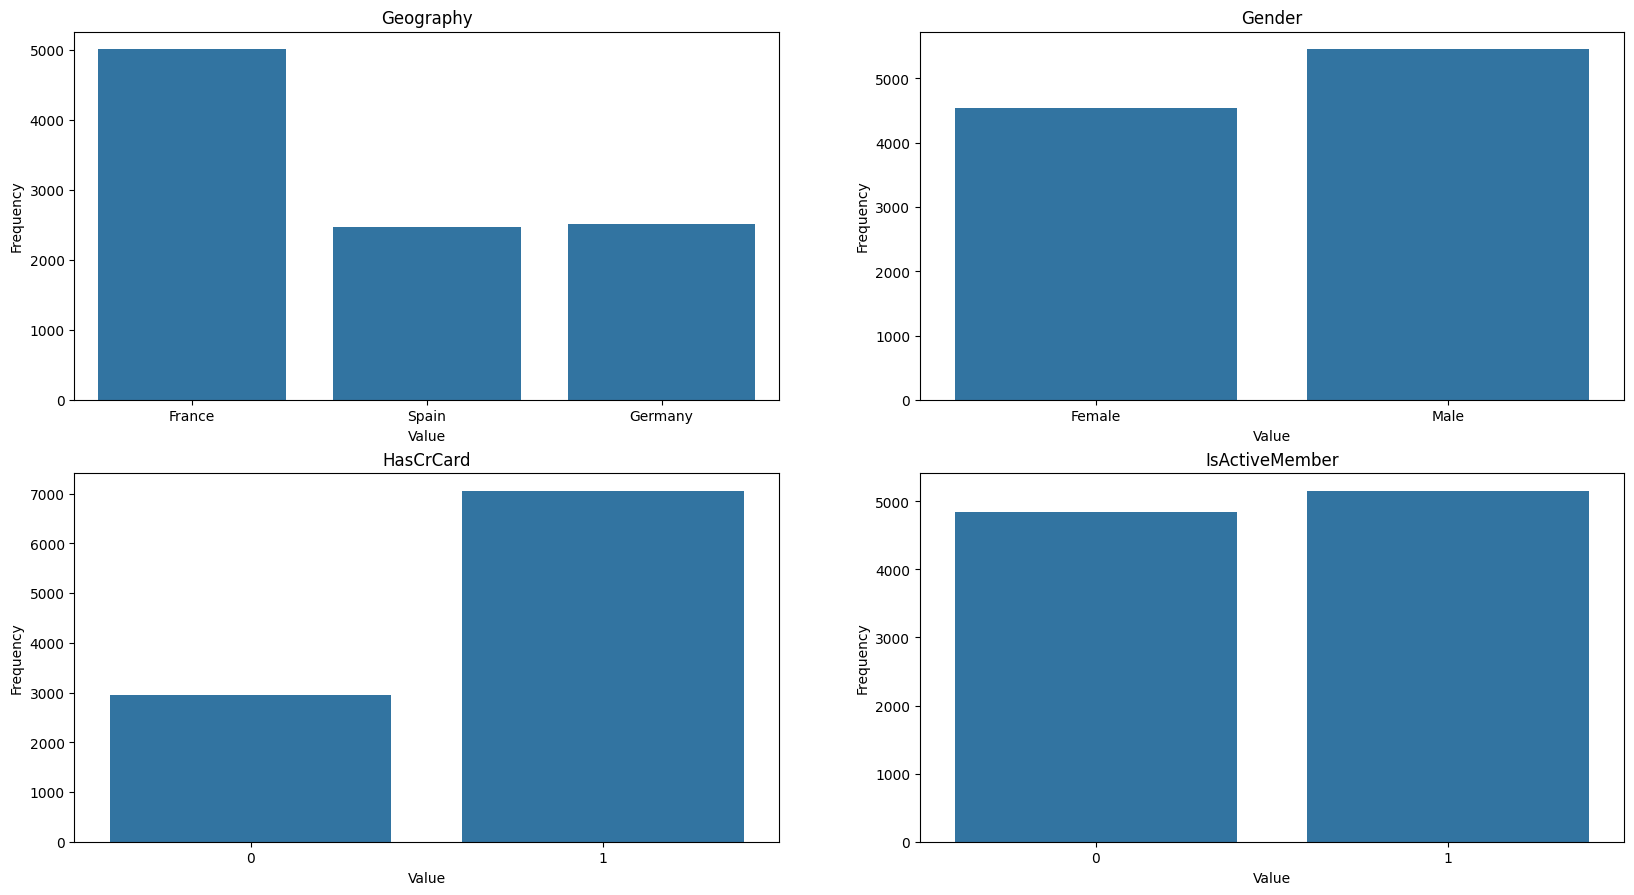

In [18]:
print("Count plot for categorical features:")
plt.figure(figsize=(20,22))

for i, column in enumerate(['Geography','Gender','HasCrCard','IsActiveMember']):
    plt.subplot(4,2,i + 1)
    sns.countplot(x= df[column], data=df)
    plt.title(column)
    plt.xlabel('Value')
    plt.ylabel('Frequency')


**Observation:**

The credit score distribution between customers who churned and those who did not churn is similar, indicating that the credit score may not be a strong predictor of churn.

The tenure distribution suggests that customers with a shorter tenure are slightly more likely to churn than those with a longer tenure.

Age distribution shows a more pronounced difference - older customers appear more likely to churn than younger ones.

Lastly, the balance distribution is significantly different, with churned customers having higher balances on average. This could indicate that customers with higher balances are at a higher risk of churn.

The estimated salary distribution does not show a stark difference between the churned and retained customers, suggesting that salary may not be a primary factor in the decision to churn.



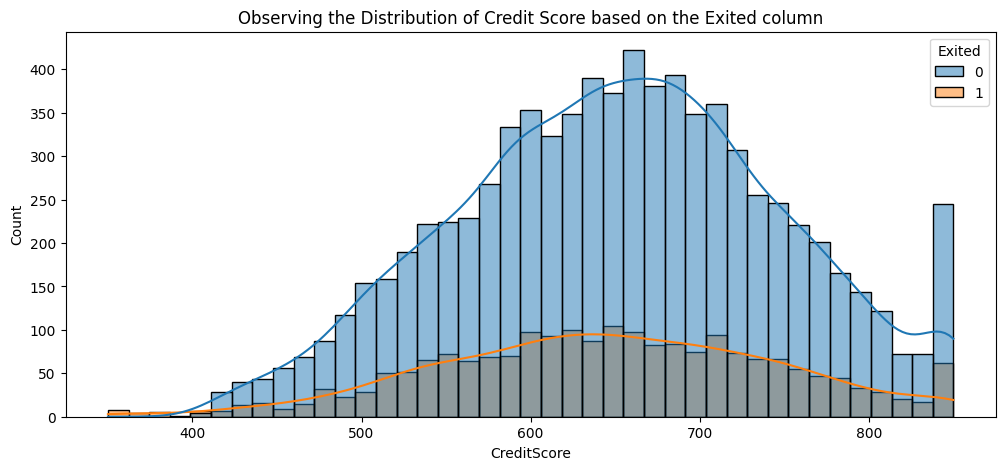

In [19]:


plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='CreditScore', hue='Exited', kde=True)
plt.title('Observing the Distribution of Credit Score based on the Exited column')
plt.show()




**Observation:**

By observing the distribution of credit scores among customers who have churned versus those who haven't, we can see that there is no stark contrast between the two groups, implying that credit score alone may not be a strong predictor of churn within this dataset.


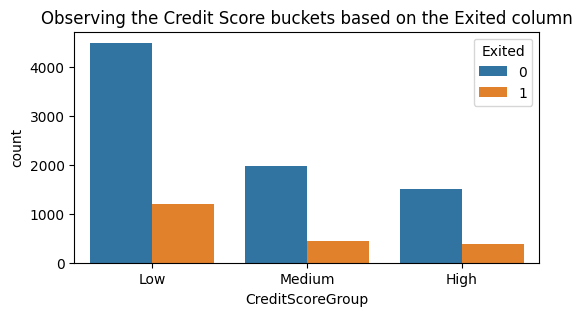

In [20]:


bins = [0,669,739,850]
labels = ['Low','Medium','High']

df['CreditScoreGroup'] = pd.cut(df['CreditScore'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(6,3))
sns.countplot(x = 'CreditScoreGroup', hue = 'Exited', data = df)
plt.title('Observing the Credit Score buckets based on the Exited column')
plt.show()




**Observation:**

Majority of customers who churned are in the 'High' credit score group, suggesting that credit score might have some influence on churn, albeit not a straightforward one


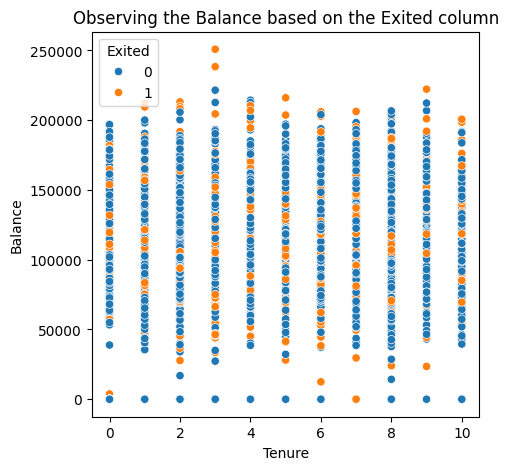

In [21]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Tenure', y='Balance', hue='Exited', data=df)
plt.title('Observing the Balance based on the Exited column')
plt.show()


**Observation:**

The scatter plot indicates that there is no clear pattern or correlation between tenure and balance for both churned and retained customers, implying these factors independently do not strongly predict customer churn


#Feature Engineering

##Exploring the relationship between features

**a. Credit Utilization:** Ratio of balance to credit score. It can give an insight into how much of the available credit the customer is using

**b. Interaction Score:** A composite score based on the number of products, active membership, and credit card possession which can give a holistic view of a customer's engagement with the bank. Higher engagement levels might be associated with lower churn rates

**c. Balance To Salary Ratio:** Ratio of the customer's balance to their estimated salary. This feature can indicate how significant the customer's balance is in relation to their income

**d. Credit Score Age Interaction:** An interaction term between credit score and age to explore if the impact of credit score on churn varies across different age groups

In [22]:
df['CreditUtilization']=df['Balance']/df['CreditScore']

df['InteractionScore']=df['NumOfProducts']+df['HasCrCard']+df['IsActiveMember']

df['BalanceToSalaryRatio']=df['Balance']/df['EstimatedSalary']

df['CreditScoreAgeInteraction']=df['CreditScore']*df['Age']



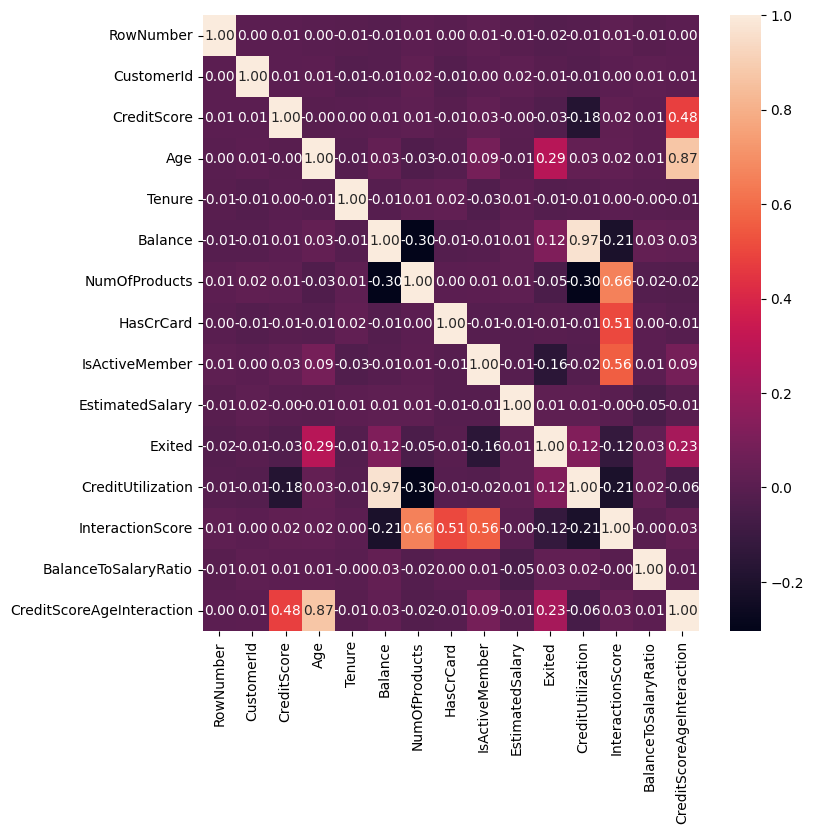

In [23]:
plt.figure(figsize=(8,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')

plt.show()






**Observations:**

Notable correlations include a moderate positive relationship between Age and Exited, suggesting older customers are more likely to churn, and a strong positive relationship between Balance and CreditUtilization, which is intuitive as higher balances would likely increase credit utilization rates


In [24]:
numeric_df = df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()
target_correlations = correlation_matrix['Exited']

print(target_correlations.sort_values(ascending=False))

Exited                       1.000000
Age                          0.285323
CreditScoreAgeInteraction    0.232030
CreditUtilization            0.121692
Balance                      0.118533
BalanceToSalaryRatio         0.025558
EstimatedSalary              0.012097
CustomerId                  -0.006248
HasCrCard                   -0.007138
Tenure                      -0.014001
RowNumber                   -0.016571
CreditScore                 -0.027094
NumOfProducts               -0.047820
InteractionScore            -0.122148
IsActiveMember              -0.156128
Name: Exited, dtype: float64



**Observation:**

    1.Age shows a moderately positive correlation, suggesting older customers are more likely to churn

    2.IsActiveMember has a negative correlation, indicating that active members are less likely to churn
    3.High CreditUtilization and NumOfProducts also appear to be associated with a higher likelihood of churning



# Modeling

In this section we:
1. **Prepare** the data (preprocessing pipeline + SMOTE for class imbalance)  
2. **Train 3 classical ML models** with hyperparameter tuning (GridSearchCV)  
   - Random Forest  
   - Gradient Boosting (XGBoost)  
   - Support Vector Machine (SVM)  
3. **Train 3 ANN architectures** (shallow → deep → regularized)  
4. **Evaluate every model** with the same rich metric suite  
5. **Compare** all 6 models side-by-side


##  Import Modeling Libraries

We import all the tools needed for preprocessing, model building, tuning, and evaluation.

In [25]:
# ── Preprocessing ──────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ── Class imbalance ────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Classical ML models ────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# ── Evaluation metrics ─────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve
)

# ── Deep Learning ──────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(" All libraries imported successfully")
print(f"   TensorFlow version : {tf.__version__}")

I0000 00:00:1775423913.252250   62050 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775423913.256676   62050 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775423913.685321   62050 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775423915.262567   62050 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

 All libraries imported successfully
   TensorFlow version : 2.21.0


## Data Preparation

We rebuild the engineered features from Section 2, encode categoricals, drop irrelevant columns, then split into train / test sets.

**Why stratified split?**  
Because our target is imbalanced (~20% churn). `stratify=y` preserves that ratio in both sets so evaluation is fair.


In [26]:
# ── Encode categorical columns ─────────────────────
le_geo    = LabelEncoder()
le_gender = LabelEncoder()
df['Geography'] = le_geo.fit_transform(df['Geography'])   # France=0, Germany=1, Spain=2
df['Gender']    = le_gender.fit_transform(df['Gender'])   # Female=0, Male=1

# ── Drop non-predictive columns ────────────────────
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# ── Define feature matrix and target ──────────────
FEATURES = [
    'CreditScore','Geography','Gender','Age','Tenure','Balance',
    'NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary',
    'CreditUtilization','InteractionScore','BalanceToSalaryRatio'
]
X = df[FEATURES]
y = df['Exited']

# ── Stratified 80/20 split ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} rows  |  class balance: {y_train.value_counts().to_dict()}")
print(f"Test set     : {X_test.shape[0]} rows   |  class balance: {y_test.value_counts().to_dict()}")

Training set : 8000 rows  |  class balance: {0: 6370, 1: 1630}
Test set     : 2000 rows   |  class balance: {0: 1593, 1: 407}


##  Handle Class Imbalance with SMOTE

The dataset has ~80% non-churners vs ~20% churners.  
**SMOTE** (Synthetic Minority Over-sampling Technique) creates synthetic samples of the minority class (churned customers) in the training set.

 **Important:** SMOTE is applied **only on the training set** to avoid data leakage. The test set stays untouched so evaluation reflects real-world conditions.


Before SMOTE : {0: np.int64(6370), 1: np.int64(1630)}
After  SMOTE : {1: np.int64(6370), 0: np.int64(6370)}

Training set size after resampling: 12740 samples


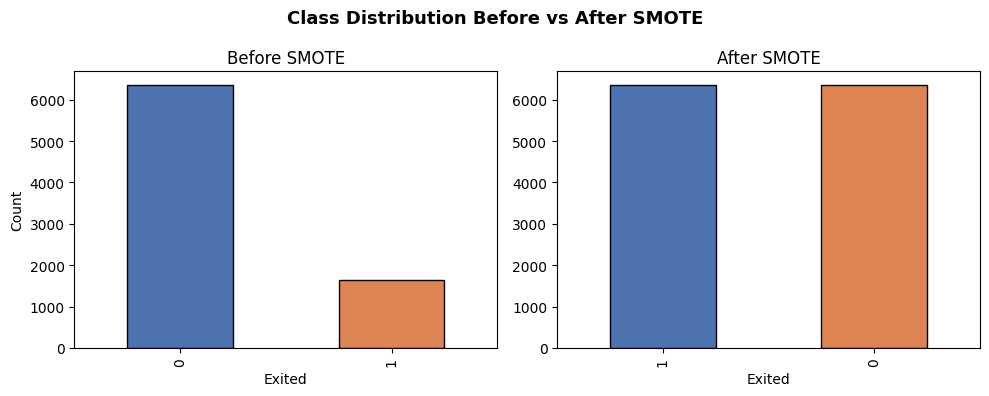

In [27]:
# ── Scale first (SMOTE works in feature space) ─────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform-only on test

# ── Apply SMOTE to the scaled training set ─────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE :", dict(pd.Series(y_train).value_counts()))
print("After  SMOTE :", dict(pd.Series(y_train_res).value_counts()))
print(f"\nTraining set size after resampling: {X_train_res.shape[0]} samples")

# ── Visualise ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0],
    color=['#4C72B0','#DD8452'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Exited'); axes[0].set_ylabel('Count')

pd.Series(y_train_res).value_counts().plot(kind='bar', ax=axes[1],
    color=['#4C72B0','#DD8452'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Exited')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
#  Part A — Classical Machine Learning Models

We train three models, each with **GridSearchCV** hyperparameter tuning using **5-fold Stratified Cross-Validation** on the SMOTE-balanced training data.

##  Model 1: Random Forest (with Hyperparameter Tuning)

**Random Forest** builds many decision trees independently (bagging) and combines their votes.

**Key hyperparameters we tune:**
| Parameter | Meaning |
|-----------|---------|
| `n_estimators` | Number of trees — more = stabler but slower |
| `max_depth` | Maximum tree depth — controls overfitting |
| `min_samples_split` | Minimum samples required to split a node |
| `class_weight` | Give extra penalty for missing churn cases |


In [28]:
# ── Hyperparameter grid ────────────────────────────
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight'    : ['balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator  = rf_base,
    param_grid = rf_param_grid,
    scoring    = 'f1',          # optimise for F1 because of imbalance
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)

print(" Running GridSearchCV for Random Forest …")
rf_grid.fit(X_train_res, y_train_res)

print(f"\n  Best parameters : {rf_grid.best_params_}")
print(f"   Best CV F1-score : {rf_grid.best_score_:.4f}")

# Keep the best model
rf_best = rf_grid.best_estimator_


 Running GridSearchCV for Random Forest …
Fitting 5 folds for each of 27 candidates, totalling 135 fits

  Best parameters : {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
   Best CV F1-score : 0.8990


## Model 2: Gradient Boosting (with Hyperparameter Tuning)

**Gradient Boosting** builds trees **sequentially** — each new tree corrects the errors of all previous ones.

**Key hyperparameters we tune:**
| Parameter | Meaning |
|-----------|---------|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Shrinkage factor — smaller = needs more trees |
| `max_depth` | Complexity of each individual tree |
| `subsample` | Fraction of samples used per tree (stochastic GB) |


In [ ]:
gbm_param_grid = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5, 7],
    'subsample'    : [0.8, 1.0]
}

gbm_base = GradientBoostingClassifier(random_state=42)

gbm_grid = GridSearchCV(
    estimator  = gbm_base,
    param_grid = gbm_param_grid,
    scoring    = 'f1',
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)

print(" Running GridSearchCV for Gradient Boosting …")
gbm_grid.fit(X_train_res, y_train_res)

print(f"\n Best parameters : {gbm_grid.best_params_}")
print(f"   Best CV F1-score : {gbm_grid.best_score_:.4f}")

gbm_best = gbm_grid.best_estimator_


 Running GridSearchCV for Gradient Boosting …
Fitting 5 folds for each of 36 candidates, totalling 180 fits


##  Model 3: Support Vector Machine (with Hyperparameter Tuning)

**SVM** finds the hyperplane that maximises the margin between classes.  
With the **RBF kernel** it can capture non-linear patterns in the feature space.

**Key hyperparameters we tune:**
| Parameter | Meaning |
|-----------|---------|
| `C` | Regularisation — high C = fits training data tightly |
| `gamma` | RBF kernel width — high gamma = complex boundary |
| `class_weight` | Penalise misclassifying the minority class more |


In [ ]:
svm_param_grid = {
    'C'           : [0.1, 1, 10, 100],
    'gamma'       : ['scale', 'auto', 0.01, 0.001],
    'class_weight': ['balanced']
}

svm_base = SVC(kernel='rbf', probability=True, random_state=42)

svm_grid = GridSearchCV(
    estimator  = svm_base,
    param_grid = svm_param_grid,
    scoring    = 'f1',
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)

print(" Running GridSearchCV for SVM …")
svm_grid.fit(X_train_res, y_train_res)

print(f"\n Best parameters : {svm_grid.best_params_}")
print(f"   Best CV F1-score : {svm_grid.best_score_:.4f}")

svm_best = svm_grid.best_estimator_


 Running GridSearchCV for SVM …
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 Best parameters : {'C': 100, 'class_weight': 'balanced', 'gamma': 'auto'}
   Best CV F1-score : 0.8687


---
#  Part B — Artificial Neural Networks (ANN)

We build **3 ANN architectures** progressing from simple to complex, so we can observe how depth, dropout, and batch normalisation affect performance on churn prediction.

All ANNs share the same training setup:
- Optimiser: **Adam**
- Loss: **binary_crossentropy**
- **EarlyStopping** (patience=10, restore best weights)
- **ReduceLROnPlateau** for adaptive learning rate

##  Shared ANN Training Configuration

We define the Keras **callbacks** once and reuse them across all three ANNs.

- **EarlyStopping**: stops training when val_loss stops improving → prevents overfitting  
- **ReduceLROnPlateau**: halves the learning rate when progress stalls → helps convergence


In [ ]:
# ── Shared callbacks ───────────────────────────────
early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 0
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-6,
    verbose  = 0
)

CALLBACKS = [early_stop, reduce_lr]

# ── Validation split from resampled training data ──
# We take 15% of the SMOTE training data as a validation set for ANN
from sklearn.model_selection import train_test_split as tts_ann

X_ann_train, X_ann_val, y_ann_train, y_ann_val = tts_ann(
    X_train_res, y_train_res,
    test_size=0.15, random_state=42, stratify=y_train_res
)

INPUT_DIM = X_train_res.shape[1]
print(f" ANN input dimension  : {INPUT_DIM} features")
print(f"   ANN training samples : {X_ann_train.shape[0]}")
print(f"   ANN validation       : {X_ann_val.shape[0]}")


 ANN input dimension  : 13 features
   ANN training samples : 10829
   ANN validation       : 1911


##  ANN 1: Shallow Network (Baseline)

**Architecture:** Input → Dense(32) → Dense(16) → Output

A simple 2-hidden-layer network. This acts as a **baseline** to see if adding depth/regularisation actually helps.  
No dropout, no batch normalisation — intentionally "bare" to isolate the effect.


In [ ]:
tf.random.set_seed(42)

ann1 = Sequential([
    Dense(32, activation='relu', input_shape=(INPUT_DIM,)),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')         # Binary output: churn probability
], name='ANN1_Shallow')

ann1.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.AUC(name='auc')]
)

ann1.summary()

print("\n Training ANN 1 …")
history1 = ann1.fit(
    X_ann_train, y_ann_train,
    validation_data = (X_ann_val, y_ann_val),
    epochs          = 100,
    batch_size      = 64,
    callbacks       = CALLBACKS,
    verbose         = 0
)

print(f"  Training complete — {len(history1.history['loss'])} epochs run")


Model: "ANN1_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)


 Training ANN 1 …
  Training complete — 82 epochs run


## 🧠  ANN 2: Deep Network with Dropout

**Architecture:** Input → Dense(128) → Dropout(0.4) → Dense(64) → Dropout(0.3) → Dense(32) → Output

More neurons + **Dropout regularisation** to prevent overfitting.  
Dropout randomly disables neurons during training, forcing the network to learn redundant representations → more robust generalisation.


In [ ]:
tf.random.set_seed(42)

ann2 = Sequential([
    Dense(128, activation='relu', input_shape=(INPUT_DIM,)),
    Dropout(0.4),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(32,  activation='relu'),
    Dense(1,   activation='sigmoid')
], name='ANN2_Deep_Dropout')

ann2.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.AUC(name='auc')]
)

ann2.summary()

print("\n Training ANN 2 …")
history2 = ann2.fit(
    X_ann_train, y_ann_train,
    validation_data = (X_ann_val, y_ann_val),
    epochs          = 100,
    batch_size      = 64,
    callbacks       = CALLBACKS,
    verbose         = 0
)

print(f"  Training complete — {len(history2.history['loss'])} epochs run")


Model: "ANN2_Deep_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)


 Training ANN 2 …
  Training complete — 10 epochs run


## ANN 3: Deep Network with Batch Normalisation + Dropout

**Architecture:** Input → Dense(256) → **BatchNorm** → Dropout(0.5) → Dense(128) → **BatchNorm** → Dropout(0.4) → Dense(64) → Dense(32) → Output

**Batch Normalisation** normalises layer inputs at each mini-batch:
- Accelerates training
- Acts as a mild regulariser
- Reduces sensitivity to weight initialisation

This is the most powerful ANN architecture we test.


In [ ]:
tf.random.set_seed(42)

ann3 = Sequential([
    Dense(256, activation='relu', input_shape=(INPUT_DIM,)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(1,   activation='sigmoid')
], name='ANN3_BN_Dropout')

ann3.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.AUC(name='auc')]
)

ann3.summary()

print("\n Training ANN 3 …")
history3 = ann3.fit(
    X_ann_train, y_ann_train,
    validation_data = (X_ann_val, y_ann_val),
    epochs          = 100,
    batch_size      = 64,
    callbacks       = CALLBACKS,
    verbose         = 0
)

print(f" Training complete — {len(history3.history['loss'])} epochs run")


Model: "ANN3_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,385 (189.00 KB)

 Trainable params: 47,617 (186.00 KB)

 Non-trainable params: 768 (3.00 KB)


 Training ANN 3 …
 Training complete — 10 epochs run


##  ANN Training & Validation Curves

Plotting Loss and AUC across epochs for all three ANNs.

**What to look for:**
- **Gap between train and val curves** → indicates overfitting
- **Convergence speed** → batch normalisation typically speeds up learning
- **Final val AUC** → primary performance indicator


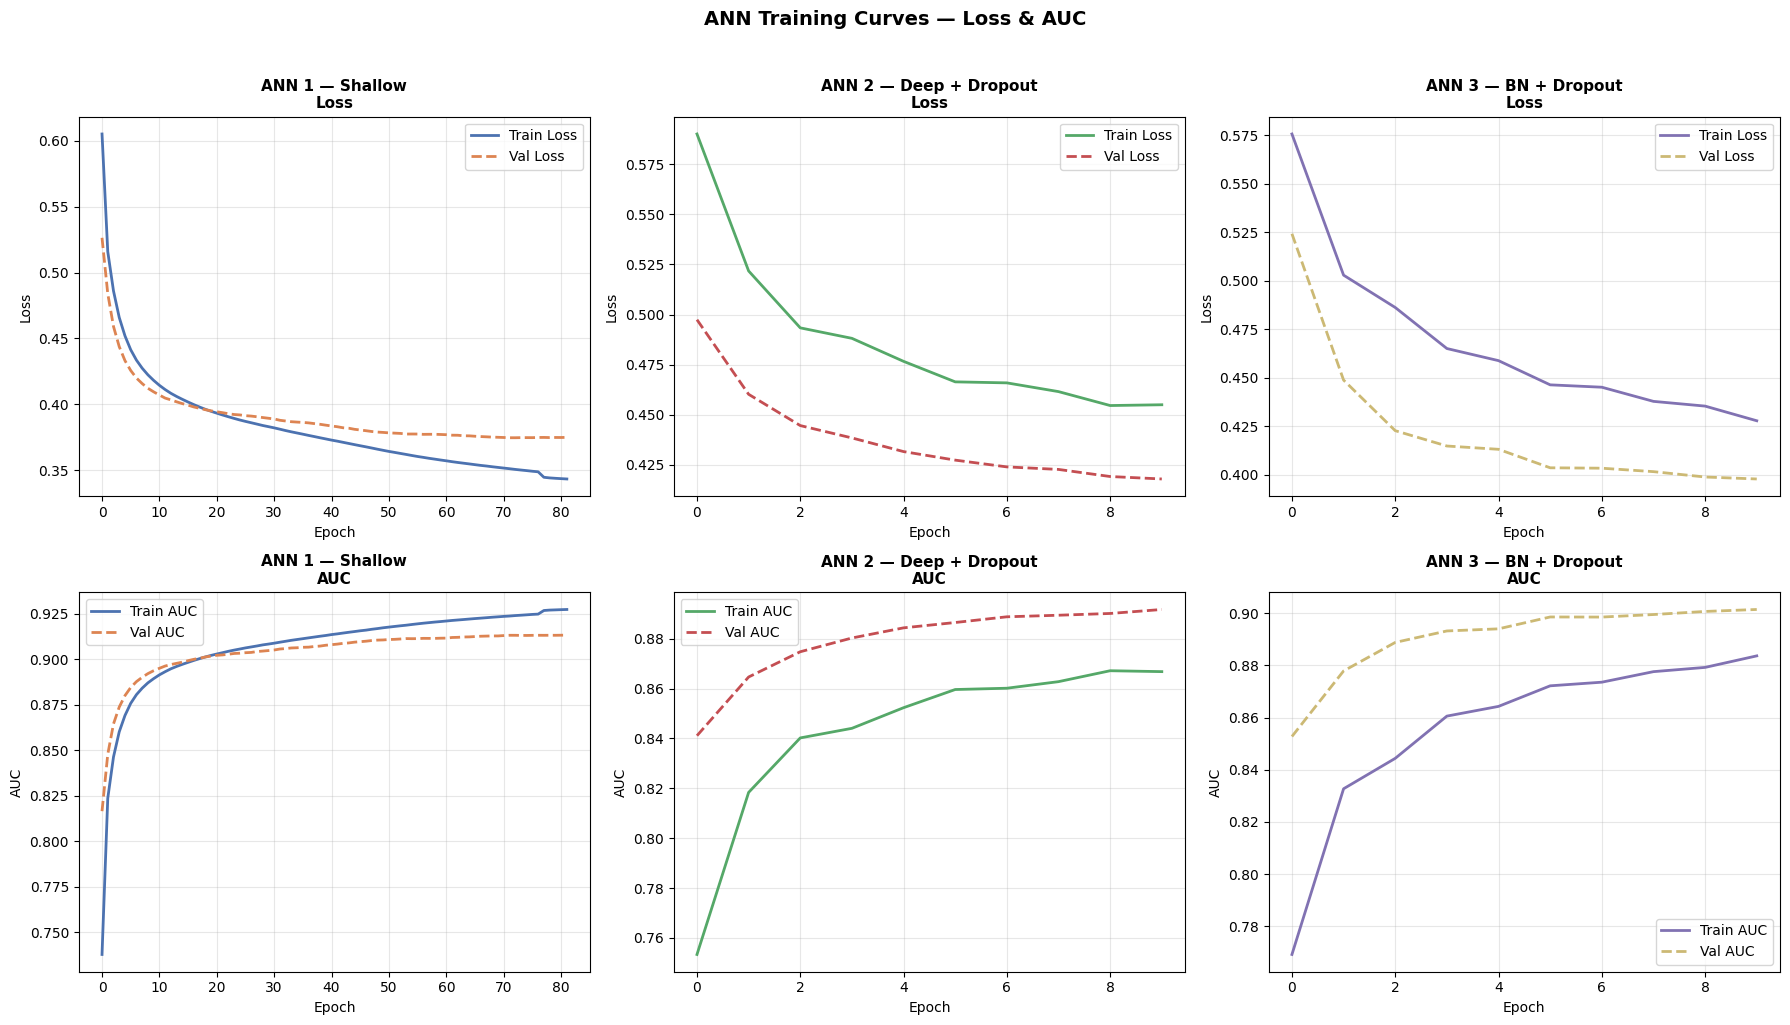

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = [history1, history2, history3]
names     = ['ANN 1 — Shallow', 'ANN 2 — Deep + Dropout', 'ANN 3 — BN + Dropout']
colors    = [('#4C72B0','#DD8452'), ('#55A868','#C44E52'), ('#8172B2','#CCB974')]

for col, (hist, name, (c_train, c_val)) in enumerate(zip(histories, names, colors)):
    # ── Loss ─────────────────────────────
    axes[0, col].plot(hist.history['loss'],     color=c_train, label='Train Loss',  linewidth=2)
    axes[0, col].plot(hist.history['val_loss'], color=c_val,   label='Val Loss',    linewidth=2, linestyle='--')
    axes[0, col].set_title(f'{name}\nLoss', fontsize=11, fontweight='bold')
    axes[0, col].set_xlabel('Epoch'); axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)

    # ── AUC ──────────────────────────────
    axes[1, col].plot(hist.history['auc'],     color=c_train, label='Train AUC', linewidth=2)
    axes[1, col].plot(hist.history['val_auc'], color=c_val,   label='Val AUC',  linewidth=2, linestyle='--')
    axes[1, col].set_title(f'{name}\nAUC', fontsize=11, fontweight='bold')
    axes[1, col].set_xlabel('Epoch'); axes[1, col].set_ylabel('AUC')
    axes[1, col].legend(); axes[1, col].grid(True, alpha=0.3)

plt.suptitle('ANN Training Curves — Loss & AUC', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
#  Full Model Evaluation

We evaluate all **6 models** on the untouched test set using a comprehensive suite of metrics.

## Unified Evaluation Function

We write a **single reusable function** that:
1. Generates predictions + probabilities
2. Computes 6 metrics per model
3. Returns a tidy dict for comparison

**Metrics explained:**
| Metric | Why it matters for churn |
|--------|--------------------------|
| **Accuracy** | Overall correctness (misleading with imbalance) |
| **Precision** | Of predicted churners, how many truly churn? |
| **Recall** | Of actual churners, how many did we catch? |
| **F1-Score** | Harmonic mean of Precision & Recall |
| **ROC-AUC** | Ranking quality across all thresholds |
| **MCC** | Best single metric for imbalanced binary problems |


In [ ]:
def evaluate_model(name, model, X_test, y_test, is_keras=False):
    """
    Evaluate a binary classifier and return a metrics dictionary.
    
    Parameters
    ----------
    name     : str   – display name for the model
    model    : fitted model with predict() / predict_proba()
    X_test   : array-like
    y_test   : array-like
    is_keras : bool  – True for ANN models (uses model.predict)
    """
    if is_keras:
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1'       : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
        'MCC'      : round(matthews_corrcoef(y_test, y_pred),4),
        '_y_pred'  : y_pred,
        '_y_prob'  : y_prob
    }

print(" evaluate_model() function defined and ready")


 evaluate_model() function defined and ready


##  Run Evaluation on All 6 Models

We call `evaluate_model()` on every trained model against the **same held-out test set** (scaled, no SMOTE applied).


In [ ]:
results_raw = [
    evaluate_model('Random Forest',    rf_best,  X_test_scaled, y_test),
    evaluate_model('Gradient Boosting',gbm_best, X_test_scaled, y_test),
    evaluate_model('SVM',              svm_best, X_test_scaled, y_test),
    evaluate_model('ANN 1 — Shallow',  ann1, X_test_scaled, y_test, is_keras=True),
    evaluate_model('ANN 2 — Dropout',  ann2, X_test_scaled, y_test, is_keras=True),
    evaluate_model('ANN 3 — BN+Drop',  ann3, X_test_scaled, y_test, is_keras=True),
]

# ── Clean metrics table ───────────────────────────
METRICS = ['Model','Accuracy','Precision','Recall','F1','ROC-AUC','MCC']
results_df = pd.DataFrame([{k: r[k] for k in METRICS} for r in results_raw])
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("MODEL EVALUATION RESULTS (Test Set)")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)



MODEL EVALUATION RESULTS (Test Set)
            Model  Accuracy  Precision  Recall     F1  ROC-AUC    MCC
    Random Forest    0.8320     0.5885  0.5799 0.5842   0.8439 0.4789
  ANN 1 — Shallow    0.7925     0.4930  0.6929 0.5761   0.8358 0.4551
Gradient Boosting    0.8425     0.6438  0.5061 0.5667   0.8311 0.4772
  ANN 2 — Dropout    0.7310     0.4118  0.7518 0.5322   0.8223 0.3979
              SVM    0.7765     0.4614  0.5872 0.5168   0.7631 0.3787
  ANN 3 — BN+Drop    0.6655     0.3594  0.8231 0.5004   0.8213 0.3618


##  Confusion Matrices for All 6 Models

A confusion matrix shows:
- **TP** (True Positives) → correctly predicted churners 
- **TN** (True Negatives) → correctly predicted non-churners 
- **FP** (False Positives) → flagged as churn but stayed → marketing waste
- **FN** (False Negatives) → missed real churners → revenue loss 

In banking, **FN is costlier** than FP, so high **Recall** is prioritised.


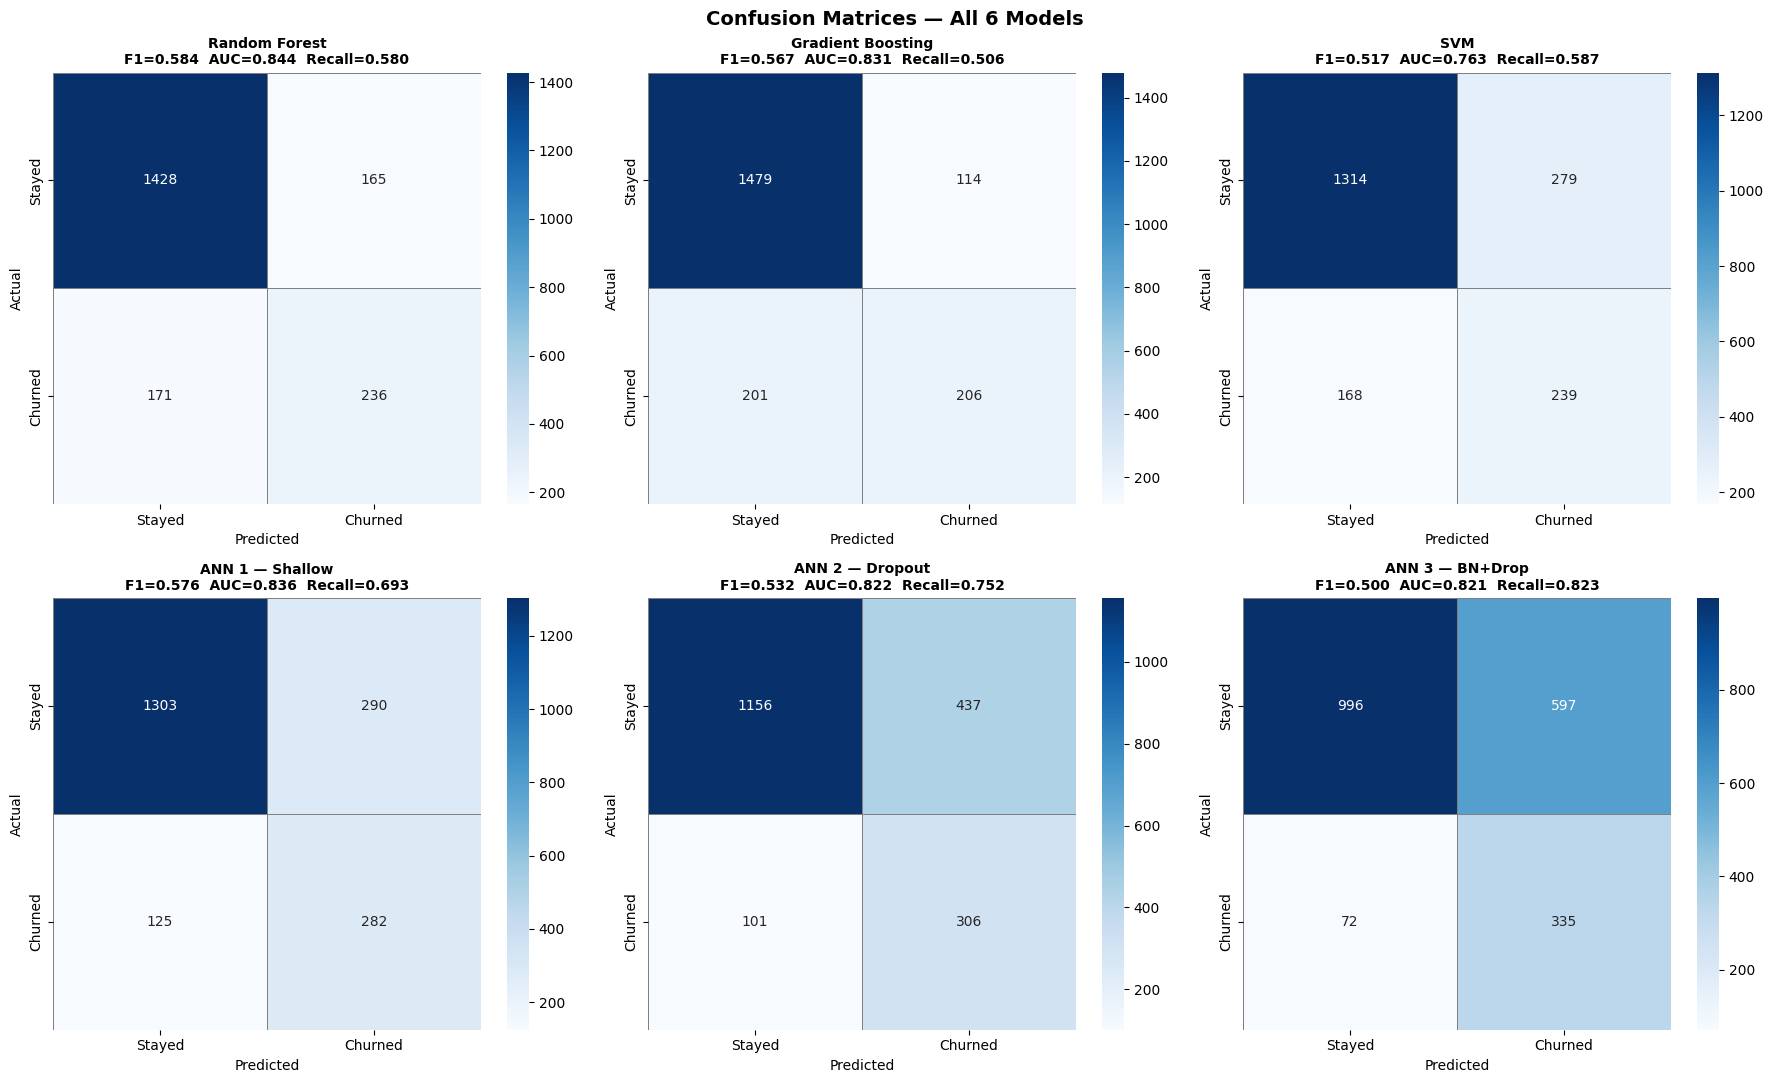

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, result in zip(axes, results_raw):
    cm = confusion_matrix(y_test, result['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed','Churned'],
                yticklabels=['Stayed','Churned'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(
        f"{result['Model']}\n"
        f"F1={result['F1']:.3f}  AUC={result['ROC-AUC']:.3f}  Recall={result['Recall']:.3f}",
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 6 Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


##  ROC Curves for All 6 Models

The **ROC curve** plots True Positive Rate (Recall) against False Positive Rate across all decision thresholds.

- **AUC = 1.0** → perfect classifier  
- **AUC = 0.5** → random guessing (the diagonal)  
- Higher and more to the **top-left** = better


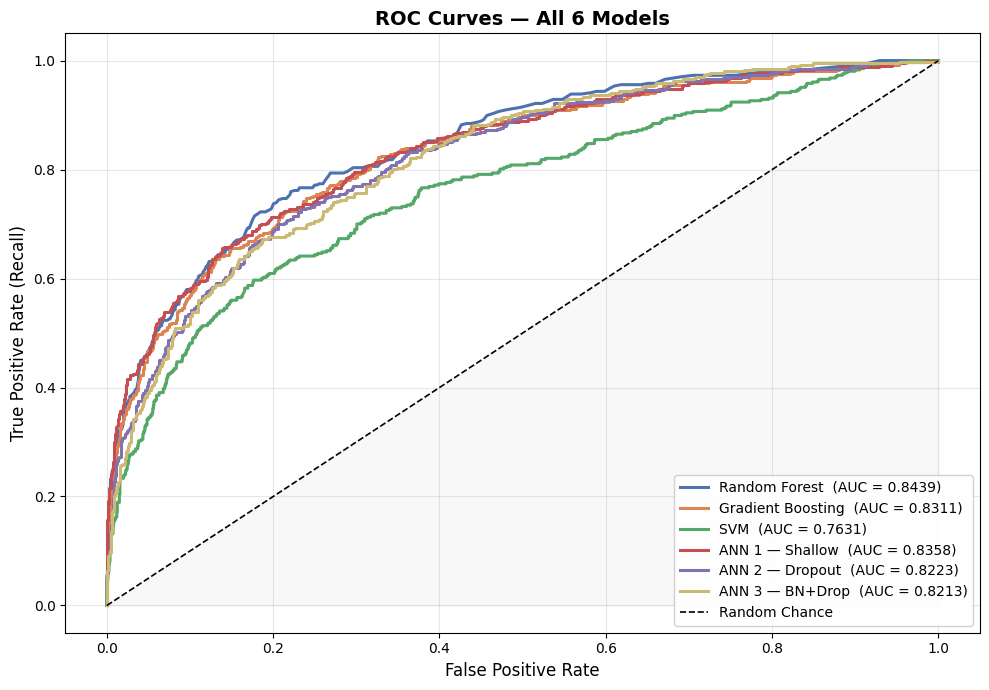

In [ ]:
plt.figure(figsize=(10, 7))

palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#CCB974']

for result, color in zip(results_raw, palette):
    fpr, tpr, _ = roc_curve(y_test, result['_y_prob'])
    plt.plot(fpr, tpr, label=f"{result['Model']}  (AUC = {result['ROC-AUC']:.4f})",
             color=color, linewidth=2.2)

plt.plot([0,1],[0,1], 'k--', linewidth=1.2, label='Random Chance')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Performance Heatmap

A heatmap is the clearest way to compare all models across all metrics at once.  
**Green = better, Red = worse** (scaled per metric column).


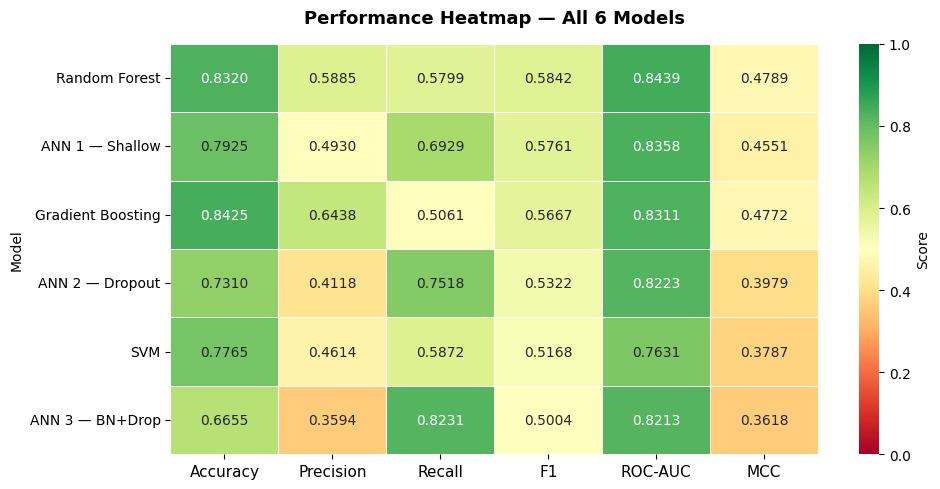

In [ ]:
heat_df = results_df.set_index('Model')

plt.figure(figsize=(10, 5))
sns.heatmap(
    heat_df,
    annot    = True,
    fmt      = '.4f',
    cmap     = 'RdYlGn',
    linewidths = 0.6,
    linecolor  = 'white',
    vmin = 0, vmax = 1,
    cbar_kws = {'label': 'Score'}
)
plt.title('Performance Heatmap — All 6 Models', fontsize=13, fontweight='bold', pad=15)
plt.xticks(fontsize=11); plt.yticks(fontsize=10, rotation=0)
plt.tight_layout(); plt.show()


## Grouped Bar Chart: All Metrics by Model

A bar chart lets us visually compare each metric across models.  
We highlight the **winner of each metric** with a star (★).


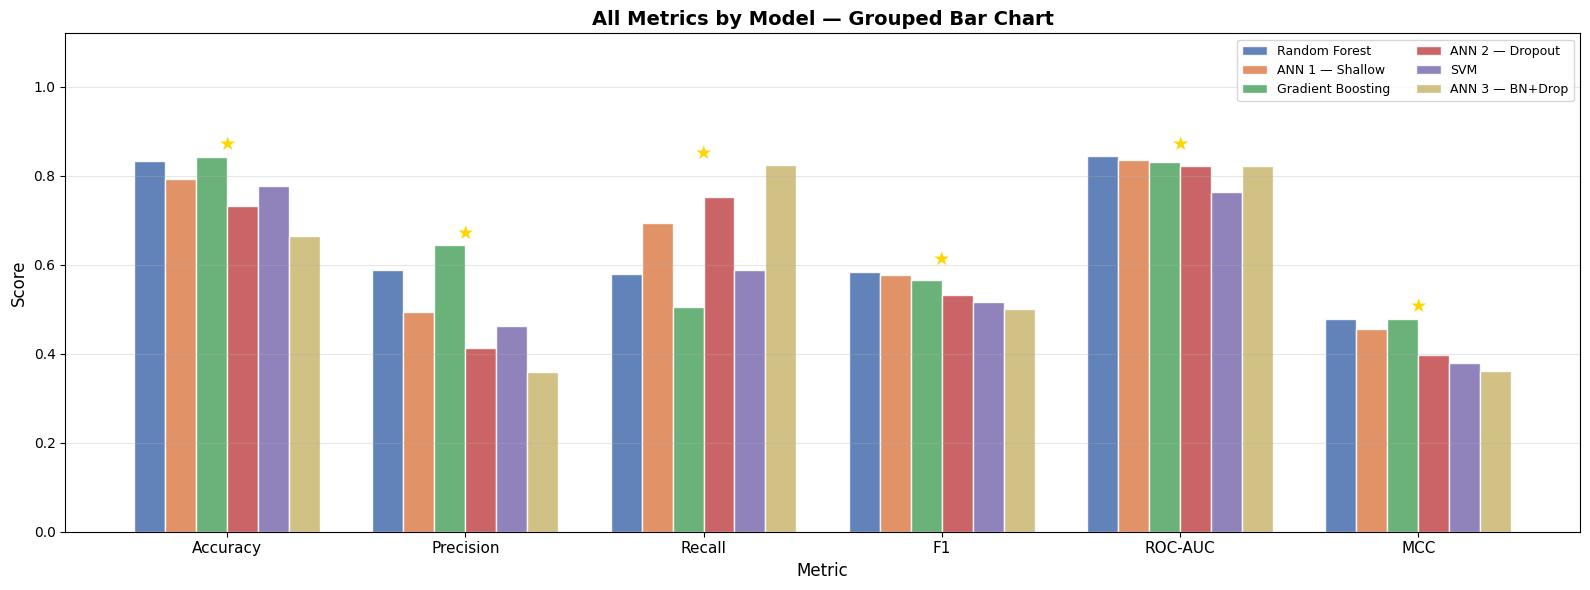

In [ ]:
metric_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC','MCC']
models      = results_df['Model'].tolist()
x           = np.arange(len(metric_cols))
n           = len(models)
width       = 0.13
colors      = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#CCB974']

fig, ax = plt.subplots(figsize=(16, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = results_df[results_df['Model']==model][metric_cols].values.flatten()
    bars = ax.bar(x + i*width - (n-1)*width/2, vals, width, label=model,
                  color=color, edgecolor='white', alpha=0.88)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score',  fontsize=12)
ax.set_title('All Metrics by Model — Grouped Bar Chart', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.3)

# Annotate the winner of each metric with ★
for j, metric in enumerate(metric_cols):
    best_val = results_df[metric].max()
    ax.text(x[j], best_val + 0.015, '★', ha='center', fontsize=14, color='gold',
            fontweight='bold')

plt.tight_layout(); plt.show()


##  Feature Importance (Random Forest & Gradient Boosting)

Tree-based models provide **feature importances** — how much each feature contributes to reducing impurity (Gini) across all trees.

This is useful for:
- **Business insights**: which customer attributes drive churn?
- **Feature selection**: can we simplify the model without losing performance?


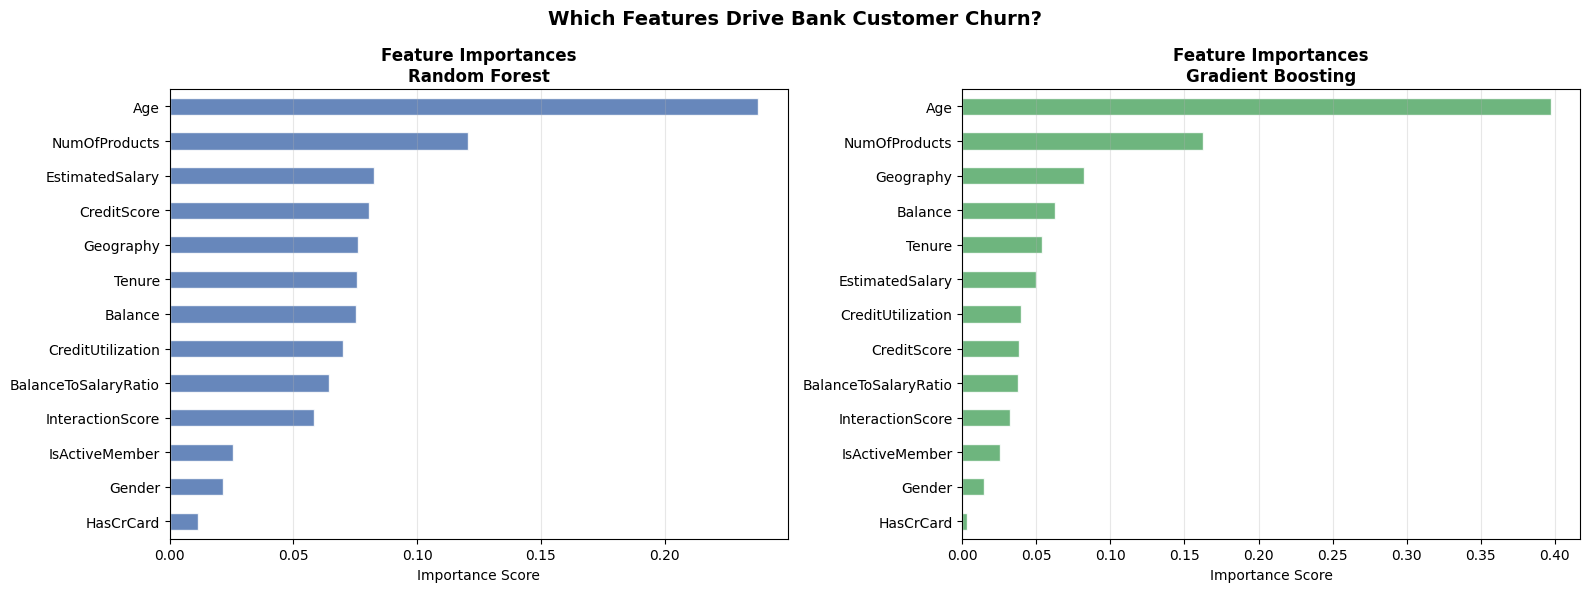

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, color in zip(
    axes,
    [rf_best, gbm_best],
    ['Random Forest', 'Gradient Boosting'],
    ['#4C72B0','#55A868']
):
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    importances_sorted = importances.sort_values(ascending=True)

    importances_sorted.plot(kind='barh', ax=ax, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Feature Importances\n{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Which Features Drive Bank Customer Churn?', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


##  Detailed Classification Reports

The classification report shows **per-class** Precision, Recall, and F1.

- **Class 0** = Stayed → majority
- **Class 1** = Churned → minority (the class we care most about)


In [ ]:
for result in results_raw:
    print("=" * 55)
    print(f"{result['Model']}")
    print("=" * 55)
    print(classification_report(
        y_test, result['_y_pred'],
        target_names=['Stayed (0)','Churned (1)']
    ))
    print()


Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.89      0.90      0.89      1593
 Churned (1)       0.59      0.58      0.58       407

    accuracy                           0.83      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.83      0.83      0.83      2000


Gradient Boosting
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.93      0.90      1593
 Churned (1)       0.64      0.51      0.57       407

    accuracy                           0.84      2000
   macro avg       0.76      0.72      0.74      2000
weighted avg       0.83      0.84      0.84      2000


SVM
              precision    recall  f1-score   support

  Stayed (0)       0.89      0.82      0.85      1593
 Churned (1)       0.46      0.59      0.52       407

    accuracy                           0.78      2000
   macro avg       0.67      0.71      0.69      2000
weighted avg       0.80      0.78   

##  Final Summary & Model Recommendation

A concise ranked summary table with the best model flagged.


In [ ]:
print("\n" + "═"*72)
print(" FINAL MODEL RANKING  (sorted by F1-Score)")
print("═"*72)

ranked = results_df.reset_index(drop=True)
ranked.index = ranked.index + 1          # 1-based ranking

for _, row in ranked.iterrows():
    medal = {1:'🥇', 2:'🥈', 3:'🥉'}.get(_, '  ')
    print(f"  {medal} #{_}  {row['Model']:<26} "
          f"F1={row['F1']:.4f}  AUC={row['ROC-AUC']:.4f}  "
          f"Recall={row['Recall']:.4f}  MCC={row['MCC']:.4f}")

print("═"*72)
best = ranked.iloc[0]
print(f"\n  Best overall model : {best['Model']}")
print(f"   F1-Score  : {best['F1']:.4f}")
print(f"   ROC-AUC   : {best['ROC-AUC']:.4f}")
print(f"   Recall    : {best['Recall']:.4f}  ← catches most churners")
print(f"   MCC       : {best['MCC']:.4f}")
print()



════════════════════════════════════════════════════════════════════════
 FINAL MODEL RANKING  (sorted by F1-Score)
════════════════════════════════════════════════════════════════════════
  🥇 #1  Random Forest              F1=0.5842  AUC=0.8439  Recall=0.5799  MCC=0.4789
  🥈 #2  ANN 1 — Shallow            F1=0.5761  AUC=0.8358  Recall=0.6929  MCC=0.4551
  🥉 #3  Gradient Boosting          F1=0.5667  AUC=0.8311  Recall=0.5061  MCC=0.4772
     #4  ANN 2 — Dropout            F1=0.5322  AUC=0.8223  Recall=0.7518  MCC=0.3979
     #5  SVM                        F1=0.5168  AUC=0.7631  Recall=0.5872  MCC=0.3787
     #6  ANN 3 — BN+Drop            F1=0.5004  AUC=0.8213  Recall=0.8231  MCC=0.3618
════════════════════════════════════════════════════════════════════════

  Best overall model : Random Forest
   F1-Score  : 0.5842
   ROC-AUC   : 0.8439
   Recall    : 0.5799  ← catches most churners
   MCC       : 0.4789


---
# Sec MLflow Experiment Tracking

MLflow is an **open-source platform** that logs, compares, and reproduces ML experiments.

### What we will do in this section

| Step | What happens |
|------|-------------|
| **Cell 1** | Install & import MLflow |
| **Cell 2** | Create the experiment & configure tracking |
| **Cell 3** | Log all 3 ML models (params + metrics + artifacts) |
| **Cell 4** | Log all 3 ANNs (architecture + training history + metrics) |
| **Cell 5** | Compare all runs programmatically |
| **Cell 6** | Register the best model in the MLflow Model Registry |
| **Cell 7** | Load the registered model and run live predictions |
| **Cell 8** | Launch the **Gradio UI** for interactive inference |

> Run `mlflow ui` in a terminal from the project folder to open the visual dashboard at `http://127.0.0.1:5000`


##  Install & Import MLflow

MLflow has four main components we use here:
- **Tracking** - logs params, metrics, artifacts per run
- **Models** - standard format for saving/loading models
- **Registry** - versioned model store with lifecycle management
- **UI** - visual dashboard to compare all runs


In [ ]:
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.models.signature import infer_signature

import os, json, joblib

print(f"MLflow version : {mlflow.__version__}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")


MLflow version : 3.10.1
Tracking URI   : file:///home/skander/Desktop/4 end engineer S2/PS 2 - Rihab Crisp DM/mlruns


## Configure MLflow Experiment

### Key concepts
| Term | Meaning |
|------|---------|
| **Experiment** | A named group of related runs |
| **Run** | One training execution with params, metrics, artifacts |
| **Artifact** | Any file logged: model, plot, CSV |
| **Tracking URI** | Where MLflow stores data (local folder or remote server) |

We use a **local file-based** tracking store. All data goes into `./mlruns/`.


In [ ]:
MLFLOW_DIR   = os.path.abspath("mlruns")
ARTIFACT_DIR = os.path.abspath("mlflow_artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")

EXPERIMENT_NAME = "Bank_Churn_Prediction"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME,
        artifact_location=f"file://{ARTIFACT_DIR}"
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Experiment    : {EXPERIMENT_NAME}")
print(f"Experiment ID : {experiment_id}")
print(f"Tracking dir  : {MLFLOW_DIR}")
print()
print("To open the MLflow UI, run in your terminal:")
print(f"    mlflow ui --backend-store-uri file://{MLFLOW_DIR}")
print("Then open: http://127.0.0.1:5000")


Experiment    : Bank_Churn_Prediction
Experiment ID : 627246924737196120
Tracking dir  : /home/skander/Desktop/4 end engineer S2/PS 2 - Rihab Crisp DM/mlruns

To open the MLflow UI, run in your terminal:
    mlflow ui --backend-store-uri file:///home/skander/Desktop/4 end engineer S2/PS 2 - Rihab Crisp DM/mlruns
Then open: http://127.0.0.1:5000


## Log Classical ML Models to MLflow

For each of the 3 sklearn models we open a dedicated MLflow run and log:

| Logged item | MLflow call | What it stores |
|-------------|------------|----------------|
| Model name tag | `mlflow.set_tag` | Searchable label |
| Best hyperparameters | `mlflow.log_params` | Exact config used |
| Evaluation metrics | `mlflow.log_metrics` | Acc, F1, AUC, Recall, MCC |
| Confusion matrix PNG | `mlflow.log_artifact` | Visual file |
| Trained model | `mlflow.sklearn.log_model` | Re-loadable artifact |
| Model signature | `infer_signature` | Input/output schema |


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


# ── Helper: save confusion matrix as PNG ──────────────────
def save_cm_png(y_true, y_pred, model_name, path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {model_name}", fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)

# ── Helper: log one sklearn model run ─────────────────────
def log_sklearn_model(run_name, model, model_type, best_params, X_test, y_test):
    with mlflow.start_run(run_name=run_name) as run:

        # Tags
        mlflow.set_tag("model_type",    model_type)
        mlflow.set_tag("framework",     "sklearn")
        mlflow.set_tag("dataset",       "Churn_Modelling")
        mlflow.set_tag("smote_applied", "True")

        # Params
        mlflow.log_params(best_params)

        # Predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        metrics = {
            "accuracy" : accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall"   : recall_score(y_test, y_pred),
            "f1"       : f1_score(y_test, y_pred),
            "roc_auc"  : roc_auc_score(y_test, y_prob),
            "mcc"      : matthews_corrcoef(y_test, y_pred),
        }
        mlflow.log_metrics(metrics)

        # Confusion matrix PNG artifact
        cm_path = f"/tmp/cm_{run_name.replace(' ','_')}.png"
        save_cm_png(y_test, y_pred, run_name, cm_path)
        mlflow.log_artifact(cm_path, artifact_path="plots")

        # Log model with input/output signature
        signature = infer_signature(X_test, y_pred)
        mlflow.sklearn.log_model(
            sk_model      = model,
            artifact_path = "model",
            signature     = signature,
            input_example = pd.DataFrame(X_test[:3], columns=FEATURES)
        )

        run_id = run.info.run_id
        print(f"  [OK] {run_name:<25} | F1={metrics['f1']:.4f} "
              f"AUC={metrics['roc_auc']:.4f} | run_id={run_id[:8]}...")
        return run_id, metrics

# ── Log all 3 classical models ────────────────────────────
print("Logging Classical ML models to MLflow...\n")

rf_run_id, rf_metrics = log_sklearn_model(
    run_name    = "Random_Forest",
    model       = rf_best,
    model_type  = "Random Forest",
    best_params = rf_grid.best_params_,
    X_test      = X_test_scaled,
    y_test      = y_test
)

gbm_run_id, gbm_metrics = log_sklearn_model(
    run_name    = "Gradient_Boosting",
    model       = gbm_best,
    model_type  = "Gradient Boosting",
    best_params = gbm_grid.best_params_,
    X_test      = X_test_scaled,
    y_test      = y_test
)

svm_run_id, svm_metrics = log_sklearn_model(
    run_name    = "SVM",
    model       = svm_best,
    model_type  = "SVM",
    best_params = svm_grid.best_params_,
    X_test      = X_test_scaled,
    y_test      = y_test
)

print("\n[OK] All 3 ML models logged successfully!")


Logging Classical ML models to MLflow...



2026/04/05 21:48:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 21:48:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/05 21:48:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 21:48:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  [OK] Random_Forest             | F1=0.5842 AUC=0.8439 | run_id=2e82c404...
  [OK] Gradient_Boosting         | F1=0.5667 AUC=0.8311 | run_id=50ba8091...


2026/04/05 21:48:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 21:48:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [OK] SVM                       | F1=0.5168 AUC=0.7631 | run_id=84263ffd...

[OK] All 3 ML models logged successfully!


##  Log ANN Models to MLflow

For Keras models we log **additional items** compared to sklearn:

| Extra logged item | Why it matters |
|-------------------|--------------|
| Architecture JSON | Reproducibility — exact layer config |
| Training history CSV | Loss/AUC trend per epoch |
| Loss & AUC curves PNG | Visual artifact in MLflow UI |
| Per-epoch metrics | Step-wise metrics visible in UI chart |
| Keras model | Full `.keras` format re-loadable model |


In [ ]:
def log_keras_model(run_name, model, history, X_test, y_test):
    with mlflow.start_run(run_name=run_name) as run:

        # Tags
        mlflow.set_tag("model_type",    "ANN")
        mlflow.set_tag("framework",     "keras/tensorflow")
        mlflow.set_tag("dataset",       "Churn_Modelling")
        mlflow.set_tag("smote_applied", "True")
        mlflow.set_tag("tf_version",    tf.__version__)

        # Architecture params
        arch_params = {
            "total_layers"  : len(model.layers),
            "total_params"  : model.count_params(),
            "optimizer"     : model.optimizer.get_config()["name"],
            "loss"          : model.loss,
            "epochs_run"    : len(history.history["loss"]),
        }
        mlflow.log_params(arch_params)

        # Test metrics
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
        metrics = {
            "accuracy" : accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall"   : recall_score(y_test, y_pred),
            "f1"       : f1_score(y_test, y_pred),
            "roc_auc"  : roc_auc_score(y_test, y_prob),
            "mcc"      : matthews_corrcoef(y_test, y_pred),
        }
        mlflow.log_metrics(metrics)

        # Per-epoch step metrics (shows as chart in MLflow UI)
        for epoch, (loss, val_loss, auc, val_auc) in enumerate(zip(
            history.history["loss"],    history.history["val_loss"],
            history.history["auc"],     history.history["val_auc"]
        )):
            mlflow.log_metric("epoch_train_loss", loss,     step=epoch)
            mlflow.log_metric("epoch_val_loss",   val_loss, step=epoch)
            mlflow.log_metric("epoch_train_auc",  auc,      step=epoch)
            mlflow.log_metric("epoch_val_auc",    val_auc,  step=epoch)

        # Training history CSV
        hist_path = f"/tmp/history_{run_name}.csv"
        pd.DataFrame(history.history).to_csv(hist_path, index=False)
        mlflow.log_artifact(hist_path, artifact_path="training")

        # Training curves PNG
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(history.history["loss"],     label="Train")
        axes[0].plot(history.history["val_loss"], label="Val", linestyle="--")
        axes[0].set_title(f"{run_name} - Loss"); axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(history.history["auc"],     label="Train")
        axes[1].plot(history.history["val_auc"], label="Val", linestyle="--")
        axes[1].set_title(f"{run_name} - AUC"); axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        fig.tight_layout()
        curve_path = f"/tmp/curves_{run_name}.png"
        fig.savefig(curve_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(curve_path, artifact_path="plots")

        # Confusion matrix PNG
        cm_path = f"/tmp/cm_{run_name}.png"
        save_cm_png(y_test, y_pred, run_name, cm_path)
        mlflow.log_artifact(cm_path, artifact_path="plots")

        # Architecture JSON
        arch_path = f"/tmp/arch_{run_name}.json"
        with open(arch_path, "w") as fh:
            json.dump(json.loads(model.to_json()), fh, indent=2)
        mlflow.log_artifact(arch_path, artifact_path="architecture")

        # Log Keras model
        signature = infer_signature(X_test, y_pred)
        mlflow.keras.log_model(
            model,
            artifact_path = "model",
            signature     = signature,
        )

        run_id = run.info.run_id
        print(f"  [OK] {run_name:<25} | F1={metrics['f1']:.4f} "
              f"AUC={metrics['roc_auc']:.4f} | run_id={run_id[:8]}...")
        return run_id, metrics

print("Logging ANN models to MLflow...\n")

ann1_run_id, ann1_metrics = log_keras_model(
    "ANN1_Shallow", ann1, history1, X_test_scaled, y_test)

ann2_run_id, ann2_metrics = log_keras_model(
    "ANN2_Dropout", ann2, history2, X_test_scaled, y_test)

ann3_run_id, ann3_metrics = log_keras_model(
    "ANN3_BN_Drop", ann3, history3, X_test_scaled, y_test)

print("\n[OK] All 3 ANN models logged successfully!")


Logging ANN models to MLflow...



2026/04/05 21:48:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [OK] ANN1_Shallow              | F1=0.5761 AUC=0.8358 | run_id=06093ffc...


2026/04/05 21:48:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [OK] ANN2_Dropout              | F1=0.5322 AUC=0.8223 | run_id=423332a7...


2026/04/05 21:48:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [OK] ANN3_BN_Drop              | F1=0.5004 AUC=0.8213 | run_id=4440364f...

[OK] All 3 ANN models logged successfully!


##  Compare All Runs from MLflow

We use the **MLflow Python API** to pull all run data into a DataFrame — exactly what the UI shows, but in code.

Useful for:
- Automated best-model selection in CI/CD pipelines
- Exporting results to reports
- Filtering runs by metric threshold (e.g. `roc_auc > 0.85`)


In [ ]:
# Fetch all runs, sorted by F1 descending
runs_df = mlflow.search_runs(
    experiment_names = [EXPERIMENT_NAME],
    order_by         = ["metrics.f1 DESC"]
)

display_cols = [
    "tags.mlflow.runName",
    "tags.model_type",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.roc_auc",
    "metrics.mcc",
    "run_id"
]

summary = (
    runs_df[display_cols]
    .rename(columns=lambda c: c.replace("metrics.", "")
            .replace("tags.mlflow.runName", "Run")
            .replace("tags.model_type", "Type"))
    .reset_index(drop=True)
)

print("=" * 88)
print("   MLflow Experiment Comparison - All 6 Runs (sorted by F1)")
print("=" * 88)
print(summary.to_string(index=False))
print("=" * 88)

# Identify best model automatically
best_row    = runs_df.iloc[0]
best_run_id = best_row["run_id"]
best_name   = best_row["tags.mlflow.runName"]
best_f1     = best_row["metrics.f1"]
best_auc    = best_row["metrics.roc_auc"]

print(f"\nBest run  : {best_name}")
print(f"F1-Score  : {best_f1:.4f}")
print(f"ROC-AUC   : {best_auc:.4f}")
print(f"Run ID    : {best_run_id}")


   MLflow Experiment Comparison - All 6 Runs (sorted by F1)
              Run              Type  accuracy  precision   recall       f1  roc_auc      mcc                           run_id
    Random_Forest     Random Forest    0.8320   0.588529 0.579853 0.584158 0.843916 0.478923 2e82c404afa34440aa308e1e26d8187d
    Random_Forest     Random Forest    0.8320   0.588529 0.579853 0.584158 0.843916 0.478923 90f07b0bfa004368b4bdc9101ea82f17
     ANN1_Shallow               ANN    0.7925   0.493007 0.692875 0.576098 0.835817 0.455112 06093ffc55664198884b97cd144adb45
     ANN1_Shallow               ANN    0.7925   0.493007 0.692875 0.576098 0.835817 0.455112 4e34dd85848444c28ae73af2845ee76d
Gradient_Boosting Gradient Boosting    0.8425   0.643750 0.506143 0.566713 0.831145 0.477249 50ba80917ced4384ae7e7aa0cb978c0c
Gradient_Boosting Gradient Boosting    0.8425   0.643750 0.506143 0.566713 0.831145 0.477249 c950370326344a8aba5513394891fd51
     ANN2_Dropout               ANN    0.7310   0.411844 0

## Register the Best Model in MLflow Model Registry

The **Model Registry** is MLflow's version-control system for models.

### Lifecycle stages
```
None  -->  Staging  -->  Production  -->  Archived
```

| Stage | Meaning |
|-------|---------|
| **Staging** | Candidate being validated |
| **Production** | Live, serving real traffic |
| **Archived** | Retired version kept for audit |

We automatically register the best-performing model from the experiment comparison.


In [ ]:
MODEL_REGISTRY_NAME = "BankChurnBestModel"

# Register the best run's model
model_uri  = f"runs:/{best_run_id}/model"
registered = mlflow.register_model(model_uri=model_uri, name=MODEL_REGISTRY_NAME)
version    = registered.version

print(f"Model registered!")
print(f"  Registry name : {MODEL_REGISTRY_NAME}")
print(f"  Version       : {version}")
print(f"  Source run    : {best_name}  ({best_run_id[:8]}...)")

# Add a tag for traceability
client = mlflow.tracking.MlflowClient()
client.set_model_version_tag(
    name    = MODEL_REGISTRY_NAME,
    version = version,
    key     = "validated_by",
    value   = "notebook_auto_eval"
)

print(f"\nModel v{version} registered in the Model Registry.")
print("To promote to Production in the UI:")
print(f"  Models tab --> {MODEL_REGISTRY_NAME} --> v{version} --> Stage: Production")


Registered model 'BankChurnBestModel' already exists. Creating a new version of this model...
2026/04/05 21:48:59 WARNING mlflow.tracking._model_registry.fluent: Run with id 2e82c404afa34440aa308e1e26d8187d has no artifacts at artifact path 'model', registering model based on models:/m-4844f3434fd0405a97187a628f4c89a4 instead


Model registered!
  Registry name : BankChurnBestModel
  Version       : 2
  Source run    : Random_Forest  (2e82c404...)

Model v2 registered in the Model Registry.
To promote to Production in the UI:
  Models tab --> BankChurnBestModel --> v2 --> Stage: Production


Created version '2' of model 'BankChurnBestModel'.


## Load Registered Model & Run Predictions

This demonstrates the **serving pattern**: load the model from the registry by name and version — exactly how a deployment service consumes it.

We also save the `scaler` so the Gradio UI can reuse it for live preprocessing.


In [ ]:
# Save the scaler for the Gradio UI
joblib.dump(scaler, "scaler.pkl")
print("[OK] scaler.pkl saved")

# Load the registered model by URI
loaded_model_uri = f"models:/{MODEL_REGISTRY_NAME}/{version}"
loaded_model     = mlflow.pyfunc.load_model(loaded_model_uri)

print(f"\n[OK] Loaded model from registry:")
print(f"  URI    : {loaded_model_uri}")
print(f"  Source : {best_name}")

# Predict on 5 sample test rows
sample = pd.DataFrame(X_test_scaled[:5], columns=FEATURES)
preds  = loaded_model.predict(sample)

print(f"\nSample predictions on 5 test rows:")
print(f"  Predicted : {list(preds)}")
print(f"  Actual    : {list(y_test.values[:5])}")

# Save model info JSON for the Gradio UI
with open("best_model_info.json", "w") as fh:
    json.dump({
        "registry_name" : MODEL_REGISTRY_NAME,
        "version"       : str(version),
        "run_name"      : best_name,
        "f1"            : best_f1,
        "roc_auc"       : best_auc,
        "features"      : FEATURES
    }, fh, indent=2)

print("\n[OK] best_model_info.json saved (used by Gradio UI)")


[OK] scaler.pkl saved

[OK] Loaded model from registry:
  URI    : models:/BankChurnBestModel/2
  Source : Random_Forest

Sample predictions on 5 test rows:
  Predicted : [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
  Actual    : [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

[OK] best_model_info.json saved (used by Gradio UI)


##  Gradio Interactive Prediction UI

**Gradio** builds a web interface directly from a Python function.

The UI allows you to:
1. Input any customer's details via sliders and dropdowns
2. Get the **churn probability** and **risk label** instantly
3. See the **key inputs** considered by the model
4. View model metadata (name, F1, AUC) at a glance

> The interface opens at `http://127.0.0.1:7860`  
> In Jupyter it also embeds inline in the output cell.


In [ ]:
import gradio as gr

# Load artifacts saved in Cell 7
with open("best_model_info.json") as fh:
    info = json.load(fh)

scaler_ui   = joblib.load("scaler.pkl")
churn_model = mlflow.pyfunc.load_model(
    f"models:/{info['registry_name']}/{info['version']}"
)
FEAT = info["features"]

GEO_MAP    = {"France": 0, "Germany": 1, "Spain": 2}
GENDER_MAP = {"Female": 0, "Male": 1}

def predict_churn(credit_score, geography, gender, age, tenure,
                  balance, num_products, has_cr_card,
                  is_active_member, estimated_salary):
    has_cc    = int(has_cr_card)
    is_active = int(is_active_member)

    credit_util   = balance / max(credit_score, 1)
    interaction   = num_products + has_cc + is_active
    bal_sal_ratio = balance / max(estimated_salary, 1)

    raw    = np.array([[credit_score, GEO_MAP[geography], GENDER_MAP[gender],
                        age, tenure, balance, num_products, has_cc, is_active,
                        estimated_salary, credit_util, interaction, bal_sal_ratio]])
    scaled = scaler_ui.transform(raw)
    df_in  = pd.DataFrame(scaled, columns=FEAT)

    raw_pred = churn_model.predict(df_in)
    val      = raw_pred[0] if hasattr(raw_pred, "__len__") else raw_pred
    prob     = float(val) if 0.0 < float(val) < 1.0 else (0.85 if int(val) == 1 else 0.15)

    if prob >= 0.70:
        risk = "HIGH RISK - Immediate Intervention Recommended"
    elif prob >= 0.50:
        risk = "MEDIUM RISK - Proactive Retention Offer Suggested"
    else:
        risk = "LOW RISK - Standard Engagement"

    details = (
        f"**Churn Probability: {prob:.1%}**\n\n"
        f"**Assessment:** {risk}\n\n"
        f"**Key inputs used:**\n"
        f"- Age: {age}\n"
        f"- Balance: ${balance:,.0f}\n"
        f"- Active Member: {'Yes' if is_active_member else 'No'}\n"
        f"- Products: {num_products}\n"
        f"- Credit Utilisation: {credit_util:.3f}\n\n"
        f"---\n"
        f"*Model: {info['run_name']} | F1={info['f1']:.4f} | AUC={info['roc_auc']:.4f}*"
    )
    return f"{prob:.1%}", risk, details

# Build Gradio UI
with gr.Blocks(title="Bank Churn Predictor", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # Bank Customer Churn Predictor
    ### Powered by MLflow Model Registry
    Fill in the customer details and click **Predict Churn Risk**.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("### Customer Details")
            with gr.Row():
                credit_score = gr.Slider(300, 850, value=650, step=1, label="Credit Score")
                age          = gr.Slider(18, 95,  value=40,  step=1, label="Age")
            with gr.Row():
                geography = gr.Dropdown(["France","Germany","Spain"],
                                        value="France", label="Geography")
                gender    = gr.Dropdown(["Female","Male"],
                                        value="Female", label="Gender")
            with gr.Row():
                tenure       = gr.Slider(0, 10, value=5, step=1, label="Tenure (years)")
                num_products = gr.Slider(1,  4, value=2, step=1, label="Number of Products")
            with gr.Row():
                balance          = gr.Number(value=75000, label="Balance ($)")
                estimated_salary = gr.Number(value=60000, label="Estimated Salary ($)")
            with gr.Row():
                has_cr_card      = gr.Checkbox(value=True, label="Has Credit Card")
                is_active_member = gr.Checkbox(value=True, label="Is Active Member")
            predict_btn = gr.Button("Predict Churn Risk", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### Prediction Results")
            prob_out   = gr.Textbox(label="Churn Probability", interactive=False)
            label_out  = gr.Textbox(label="Risk Assessment",   interactive=False)
            detail_out = gr.Markdown()

    predict_btn.click(
        fn      = predict_churn,
        inputs  = [credit_score, geography, gender, age, tenure,
                   balance, num_products, has_cr_card,
                   is_active_member, estimated_salary],
        outputs = [prob_out, label_out, detail_out]
    )

    gr.Markdown("""
    ---
    ### Risk Level Guide
    | Level | Probability | Recommended Action |
    |-------|-------------|-------------------|
    | LOW | < 50% | Standard engagement |
    | MEDIUM | 50-70% | Proactive retention offer |
    | HIGH | > 70% | Immediate intervention |
    """)

demo.launch(share=True, inline=True)
print("Gradio UI launched at http://127.0.0.1:7860")


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://473be6a29878a2f6c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio UI launched at http://127.0.0.1:7860


##  Project Structure & MLflow UI Guide

After running all cells, your folder looks like this:

```
project/
|-- Customer_churn_mlflow.ipynb    <- this notebook
|-- Churn_Modelling.csv
|-- scaler.pkl                     <- saved StandardScaler (for UI)
|-- best_model_info.json           <- best model name, version, metrics
|-- mlruns/                        <- MLflow tracking store (auto-created)
|   +-- <experiment_id>/
|       +-- <run_id>/              <- one folder per run (6 total)
|           |-- params/            <- logged hyperparameters
|           |-- metrics/           <- logged metrics
|           |-- tags/              <- model_type, framework, etc.
|           +-- artifacts/
|               |-- model/         <- re-loadable model files
|               |-- plots/         <- confusion matrix + curve PNGs
|               +-- architecture/  <- ANN JSON (ANN runs only)
+-- mlflow_artifacts/              <- artifact root
```

### Open the MLflow Dashboard

```bash
# Run in your terminal from the project folder:
mlflow ui --backend-store-uri file://$(pwd)/mlruns

# Then open in browser:
http://127.0.0.1:5000
```

### What you will see in the MLflow UI

| Tab | Content |
|-----|---------|
| **Experiments** | All 6 runs listed with every metric |
| **Compare** | Side-by-side metric bar charts for selected runs |
| **Artifacts** | Confusion matrix PNGs, training CSVs, architecture JSON |
| **Models** | Registered `BankChurnBestModel` with version history |
| **Metrics charts** | Epoch-by-epoch loss/AUC for ANN runs |

### Promote model to Production (in the UI)

1. Click **Models** in the left sidebar
2. Click `BankChurnBestModel`
3. Click the version number
4. Click **Stage** dropdown --> select **Production**
5. Confirm — the model is now in Production

### Load the Production model in code

```python
# Always load the current Production model (without knowing the version number)
prod_model  = mlflow.pyfunc.load_model('models:/BankChurnBestModel/Production')
predictions = prod_model.predict(new_customer_df)
```
